In [4]:
import pandas as pd
scorecard = pd.DataFrame({'Fund': ['Fund A', 'Fund B'],'Score': [95, 88]})

In [ ]:
import pandas as pd
alpha_beta_df = pd.DataFrame({'Fund': ['Fund A', 'Fund B'],'Alpha': [0.05, 0.08],'Beta': [0.95, 1.10]})

In [ ]:
scorecard.to_csv('../reports/fund_scorecard.csv', index=False)
alpha_beta_df.to_csv('../reports/alpha_beta.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# getting data from 02_nav_history_cleaned.csv
df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
#all columns

df.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [ ]:
#convert date column

df['date'] = pd.to_datetime(df['date'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [17]:
#sorting by date, amif_code

df = df.sort_values(['amfi_code','date'])

In [ ]:
#calculating percentage change 
df['daily_return'] = (df.groupby('amfi_code')['nav'].pct_change())
df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


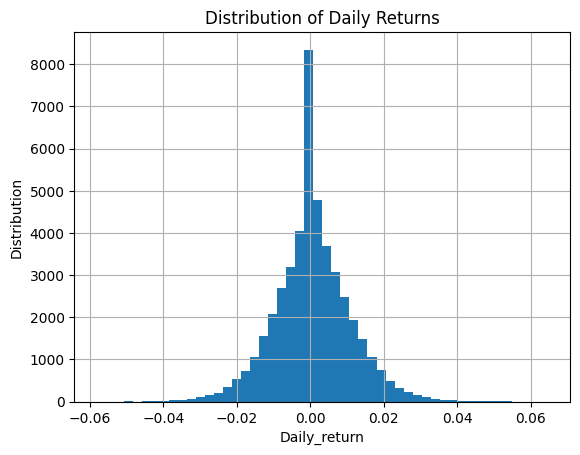

In [35]:
#creating Histogram
plt.Figure(figsize=(8,5))
df['daily_return'].hist(bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily_return")
plt.ylabel("Distribution")
plt.show()

# Daily Return Distribution Insights
Daily returns are centered around 0, indicating that most daily NAV changes are small.
The distribution is approximately bell-shaped and symmetric.
Extreme positive and negative returns are rare.
No obvious anomalies or data quality issues were observed in the return distribution.

In [37]:
df['date'].min(), df['date'].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [ ]:
df['amfi_code'].unique()
#we have 40 unique funds (schemes)

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632, 118633, 118634, 118635, 118636, 119092, 119093,
       119094, 119095, 119120, 119551, 119552, 119598, 119599, 120503,
       120504, 120505, 120506, 120507, 120841, 120842, 120843, 120844,
       125497, 125498, 148567, 148568, 148569, 149322, 149323, 149324])

In [45]:
df[df['amfi_code'] == df['amfi_code'].iloc[0]].head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [49]:
df[df['amfi_code'] == df['amfi_code'].iloc[0]].tail()

,amfi_code,date,nav,daily_return
1145,100016,2026-05-25,599.9335,-0.004227
1146,100016,2026-05-26,596.4426,-0.005819
1147,100016,2026-05-27,590.8555,-0.009367
1148,100016,2026-05-28,590.9452,0.000152
1149,100016,2026-05-29,583.6113,-0.012410


In [ ]:
# performing on  fund for sample
fund_one = df['amfi_code'].iloc[0]
fund_date = df[df['amfi_code'] == fund_one] 
fund_date[fund_date['date'] >= pd.Timestamp('2025-05-29')].head()

,amfi_code,date,nav,daily_return
888,100016,2025-05-29,596.8877,-0.002982
889,100016,2025-05-30,596.9773,0.000150
890,100016,2025-06-02,591.5240,-0.009135
891,100016,2025-06-03,601.2816,0.016496
892,100016,2025-06-04,597.0806,-0.006987


In [55]:
fund_one = df[df['amfi_code'] == 100016]
fund_date[fund_date['date'] >= '2023-05-29'].head()

,amfi_code,date,nav,daily_return
365,100016,2023-05-29,561.5519,-0.008540
366,100016,2023-05-30,565.9312,0.007799
367,100016,2023-05-31,562.0590,-0.006842
368,100016,2023-06-01,565.0931,0.005398
369,100016,2023-06-02,563.6716,-0.002516


In [ ]:
cagr = []
#for every unique fund i'm using for loop 
for f in df['amfi_code'].unique():
    fund_data = df[df['amfi_code'] == f].sort_values('date')
    e_nav = fund_data.iloc[-1]['nav']
    e_date = fund_data.iloc[-1]['date']

    one_year_date = e_date - pd.DateOffset(years=1)
    three_year_date = e_date - pd.DateOffset(years=3)

    start_nav_1y = fund_data[fund_data['date'] >= one_year_date].iloc[0]['nav']
    start_nav_3y = fund_data[fund_data['date'] >= three_year_date].iloc[0]['nav']

    cagr_1y = ((e_nav / start_nav_1y)**(1/1) - 1) * 100
    cagr_3y = ((e_nav / start_nav_3y)**(1/3) - 1) * 100

    cagr.append({'amfi_code': f,'CAGR_1Y': cagr_1y,'CAGR_3Y': cagr_3y})

    cagr_df = pd.DataFrame(cagr)

cagr_df.head()
cagr_df.sort_values(by='CAGR_3Y',ascending=False).head(10)
    
  

,amfi_code,CAGR_1Y,CAGR_3Y
16,119094,22.261065,35.111802
34,148567,20.360678,34.000916
24,120504,13.064279,32.487429
2,100033,53.232396,32.442459
25,120505,29.604659,31.777537
19,119551,60.437341,30.456524
30,120843,26.657082,29.582770
36,148569,39.751761,29.178902
3,101206,47.924120,28.967695
39,149324,65.138719,27.000427


# CAGR Analysis
Calculated 1-Year and 3-Year CAGR for all 40 funds.
5-Year CAGR could not be computed because the dataset spans from January 2022 to May 2026.
CAGR helps compare fund performance on an annualized basis.

In [77]:
df[['amfi_code','daily_return']].head()

,amfi_code,daily_return
0,100016,NaN
1,100016,-0.010306
2,100016,0.012865
3,100016,-0.011377
4,100016,-0.001210


In [ ]:
#sharpe Ratio
rf_rate = 0.065
sharpe = []

for s in df['amfi_code'].unique():

    scheme = df[df['amfi_code'] == s]

    daily_returns = scheme['daily_return'].dropna()

    annual_return = daily_returns.mean() * 252

    annual_risk = daily_returns.std() * np.sqrt(252)

    sharpe_value = (annual_return - rf_rate) / annual_risk

    sharpe.append({'amfi_code': s,'Sharpe_Ratio': sharpe_value})

sharpe_df = pd.DataFrame(sharpe)

sharpe_df = sharpe_df.sort_values(by='Sharpe_Ratio',ascending=False)




sharpe_df['Rank'] = sharpe_df['Sharpe_Ratio'].rank(ascending=False,method='dense')
sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,Rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0
38,149323,1.132122,6.0
2,100033,1.093699,7.0
9,118632,1.081659,8.0
3,101206,1.027213,9.0
24,120504,1.026524,10.0


# Sharpe Ratio Analysis
Sharpe Ratio was calculated using a 6.5% risk free rate.
Fund 148567 recorded the highest Sharpe Ratio (1.45).
Funds with higher Sharpe Ratios showed better risk adjusted performance.

In [ ]:
# Risk rate (6.5%)
rf_rate = 0.065
results = []

# Loop each unique mutual fund
for m in df['amfi_code'].unique():

    # Select data for the current fund
    scheme_data = df[df['amfi_code']== m]

    # Removing missing daily return values
    returns = scheme_data['daily_return'].dropna()

    # Convert average return to annual return
    annual_return = returns.mean() * 252
    negative_returns = returns[returns < 0]

    # Calculate downside risk
    downside_deviation = negative_returns.std()* np.sqrt(252)

    # Calculate Sortino Ratio
    sortino = (annual_return - rf_rate)/ downside_deviation

   
    results.append({'amfi_code': m,'Sortino_Ratio': sortino})

# Convert results list into DataFrame
sortino_df = pd.DataFrame(results)


# Higher ratio = better rank
sortino_df['Rank']= sortino_df['Sortino_Ratio'].rank(ascending=False, method='dense')

# Sort funds from highest to lowest sortino ratio
sortino_df = sortino_df.sort_values( by='Sortino_Ratio', ascending=False)

#top 10 funds
sortino_df.head(10)

,amfi_code,Sortino_Ratio,Rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


# Sortino Ratio Analysis
Sortino Ratio was calculated using a 6.5% risk free rate.
Only downside volatility was considered while measuring risk.
Fund 148567 recorded the highest Sortino Ratio (2.39).

In [90]:
benchmark_df = pd.read_csv('../data/processed/10_benchmark_indices_cleaned.csv')
benchmark_df.head()


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [91]:
benchmark_df['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [ ]:
# regression function
# for the proper underastanding explained every step
from scipy.stats import linregress

# Convert benchmark date column to datetime
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

# Select only nifty100 benchmark data
nifty100_df = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()

# sort benchmark data by date
nifty100_df = nifty100_df.sort_values('date')

# calculate nifty100 daily returns
nifty100_df['nifty_return'] = (nifty100_df['close_value'].pct_change())


alpha_beta_results = []

# Loop through each fund
for scheme in df['amfi_code'].unique():

    # select one fund
    scheme_data = df[df['amfi_code'] == scheme]

    # merge fund returns with nifty100 returns using date
    merged_df = pd.merge(scheme_data,nifty100_df[['date', 'nifty_return']],on='date',how='inner')

    # remove missing values
    merged_df = merged_df.dropna()

    # run linear regression
    regression_result = linregress(merged_df['nifty_return'],merged_df['daily_return'])

    # Beta = slope
    beta_value = regression_result.slope

    # alpha = intercept * 252
    alpha_value = regression_result.intercept * 252

    # store results
    alpha_beta_results.append({'amfi_code': scheme,'Alpha': alpha_value,'Beta': beta_value})

# Convert list into dataframe
alpha_beta_df = pd.DataFrame(alpha_beta_results)

# Rank funds based on alpha
alpha_beta_df['Alpha_Rank'] = alpha_beta_df['Alpha'].rank(ascending=False,method='dense')

# Sort by alpha
alpha_beta_df = alpha_beta_df.sort_values(by='Alpha',ascending=False)

# display top 10 funds
alpha_beta_df.head(10)

,amfi_code,Alpha,Beta,Alpha_Rank
21,119598,0.303370,-0.023196,1.0
39,149324,0.300579,0.011455,2.0
25,120505,0.292636,0.000549,3.0
36,148569,0.282704,0.018134,4.0
30,120843,0.273305,-0.022830,5.0
2,100033,0.271954,0.005104,6.0
34,148567,0.269838,0.023684,7.0
38,149323,0.265986,-0.002523,8.0
16,119094,0.260767,-0.066265,9.0
19,119551,0.232010,-0.031751,10.0


In [179]:
# Saving alpha beta output
alpha_beta_df.to_csv('../reports/alpha_beta.csv',index=False)

# Alpha and Beta Analysis
Alpha and Beta were calculated using nifty100 as the benchmark.
Beta measures the sensitivity of fund returns to market movements.
Alpha represents excess return generated beyond benchmark performance.
Fund 119598 recorded the highest Alpha value.

In [93]:

drawdown_results = []

In [100]:
# Process each fund
for scheme in df['amfi_code'].unique():

    # Select one fund
    scheme_data = df[df['amfi_code'] == scheme].copy()

    # Sort by date
    scheme_data = scheme_data.sort_values('date')

In [ ]:
# highest NAV reached till that date
scheme_data['running_max']=(scheme_data['nav'].cummax())
scheme_data.head()

,amfi_code,date,nav,daily_return,running_max
44850,149324,2022-01-03,81.6814,NaN,81.6814
44851,149324,2022-01-04,80.8239,-0.010498,81.6814
44852,149324,2022-01-05,80.6143,-0.002593,81.6814
44853,149324,2022-01-06,79.9386,-0.008382,81.6814
44854,149324,2022-01-07,80.8723,0.011680,81.6814


In [105]:
scheme_data.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')

In [106]:
# running maximum nav
scheme_data['running_max'] = scheme_data['nav'].cummax()

In [108]:
# calculate drawdown
scheme_data['drawdown'] = ( scheme_data['nav'] / scheme_data['running_max']) - 1


# maximum drawdown
max_drawdown = scheme_data['drawdown'].min()
print(max_drawdown)

-0.31171900300634214


In [109]:
scheme_data.columns

Index(['amfi_code', 'date', 'nav', 'daily_return', 'running_max', 'drawdown'], dtype='object')

In [ ]:
# Storing maximum drawdown results
drawdown_results = []

In [ ]:
# loop all funds
for scheme in df['amfi_code'].unique():

    #Select one fund
    scheme_data = df[df['amfi_code'] == scheme].copy()

    # Sorting data by date
    scheme_data = scheme_data.sort_values('date')

    # calculate running maximum NAV
    scheme_data['running_max'] = scheme_data['nav'].cummax()

    # calculate drawdown
    scheme_data['drawdown']=(scheme_data['nav']/ scheme_data['running_max'])- 1

    # Find worst drawdown
    max_drawdown = scheme_data['drawdown'].min()

    # Store result
    drawdown_results.append({'amfi_code': scheme,'Max_Drawdown': max_drawdown})

In [ ]:
# Converting results into dataframe
drawdown_df = pd.DataFrame(drawdown_results)
drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [ ]:
# ranking funds based on drawdown
drawdown_df['DD_Rank'] = drawdown_df['Max_Drawdown'].rank(ascending=False,method='dense')

In [ ]:
# Sorting funds by drawdown
drawdown_df = drawdown_df.sort_values(by='Max_Drawdown',ascending=False)
drawdown_df.head(10)

,amfi_code,Max_Drawdown,DD_Rank
27,120507,-0.000977,1.0
67,120507,-0.000977,1.0
107,120507,-0.000977,1.0
31,120844,-0.001163,2.0
71,120844,-0.001163,2.0
111,120844,-0.001163,2.0
5,101208,-0.001622,3.0
45,101208,-0.001622,3.0
85,101208,-0.001622,3.0
41,100025,-0.043083,4.0


In [123]:
drawdown_df.shape

(120, 3)

In [126]:
drawdown_results = []

In [127]:
for s in df['amfi_code'].unique():

    scheme_data = df[df['amfi_code'] == s].copy()

    scheme_data = scheme_data.sort_values('date')

    scheme_data['running_max'] = scheme_data['nav'].cummax()

    scheme_data['drawdown'] = (scheme_data['nav']/scheme_data['running_max']) - 1
    max_drawdown = scheme_data['drawdown'].min()
    drawdown_results.append({'amfi_code': s,'Max_Drawdown': max_drawdown})

In [129]:
drawdown_df = pd.DataFrame(drawdown_results)
drawdown_df.shape

(40, 2)

In [ ]:
# Ranking funds based on drawdown
drawdown_df['DD_Rank'] = drawdown_df['Max_Drawdown'].rank(ascending=False,method='dense')

In [ ]:
# Sorting funds by drawdown
drawdown_df = drawdown_df.sort_values(by='Max_Drawdown', ascending=False)
drawdown_df.head(10)

,amfi_code,Max_Drawdown,DD_Rank
27,120507,-0.000977,1.0
31,120844,-0.001163,2.0
5,101208,-0.001622,3.0
1,100025,-0.043083,4.0
18,119120,-0.043287,5.0
13,118636,-0.083164,6.0
6,102885,-0.108599,7.0
34,148567,-0.112657,8.0
3,101206,-0.112916,9.0
12,118635,-0.116506,10.0


In [ ]:
# Storing drawdown results
drawdown_results = []

# Loop all funds
for scheme in df['amfi_code'].unique():

    # Selecingt one fund
    scheme_data = df[df['amfi_code'] == scheme].copy()

    # Sorting by date
    scheme_data = scheme_data.sort_values('date')

    # Calculating running maximum NAV
    scheme_data['running_max'] = scheme_data['nav'].cummax()

    # Calculating drawdown
    scheme_data['drawdown'] = (scheme_data['nav']/scheme_data['running_max']) - 1

    # Maximum drawdown value
    max_drawdown = scheme_data['drawdown'].min()

    # Row where worst drawdown occurred
    worst_row = scheme_data.loc[scheme_data['drawdown'].idxmin()]

   
    trough_date = worst_row['date']

    peak_nav = worst_row['running_max']

    # Peak date
    peak_date = scheme_data[ scheme_data['nav'] == peak_nav]['date'].iloc[0]

    # Storing results
    drawdown_results.append({'amfi_code': scheme,'Max_Drawdown': max_drawdown,'Peak_Date': peak_date,'Trough_Date': trough_date})

# Creating dataframe
drawdown_df = pd.DataFrame(drawdown_results)

# Ranking funds
drawdown_df['DD_Rank'] = drawdown_df['Max_Drawdown'].rank(ascending=False,method='dense')

# Sorting by drawdown
drawdown_df = drawdown_df.sort_values( by='Max_Drawdown',ascending=False)


drawdown_df.head(10)

,amfi_code,Max_Drawdown,Peak_Date,Trough_Date,DD_Rank
27,120507,-0.000977,2025-10-16,2025-10-20,1.0
31,120844,-0.001163,2024-04-12,2024-04-30,2.0
5,101208,-0.001622,2023-09-05,2023-09-12,3.0
1,100025,-0.043083,2023-05-23,2023-07-28,4.0
18,119120,-0.043287,2024-09-16,2025-04-01,5.0
13,118636,-0.083164,2023-02-09,2024-02-09,6.0
6,102885,-0.108599,2022-02-03,2022-03-29,7.0
34,148567,-0.112657,2023-07-11,2023-10-20,8.0
3,101206,-0.112916,2023-04-24,2023-07-05,9.0
12,118635,-0.116506,2022-01-03,2022-06-09,10.0


# Maximum Drawdown Analysis
Maximum Drawdown was calculated using rolling peak NAV values.
Peak Date and Trough Date were identified for each fund's worst drawdown period.
Fund 120507 recorded the lowest drawdown (-0.10%), indicating strong downside protection.
Funds were ranked based on their Maximum Drawdown values.

In [138]:
fund_master_df = pd.read_csv('../data/processed/01_fund_master_cleaned.csv')
fund_master_df.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [139]:
# Creating rank based on 3 Year cagr
cagr_df['CAGR_Rank'] = cagr_df['CAGR_3Y'].rank(ascending=False,method='dense')

In [140]:
# Selecting required columns
expense_df = fund_master_df[['amfi_code', 'expense_ratio_pct']].copy()

# Creating expense ratio rank
expense_df['Expense_Rank'] = expense_df['expense_ratio_pct'].rank( ascending=True,method='dense')

In [145]:
scorecard.columns

Index(['amfi_code', 'CAGR_Rank', 'Sharpe_Rank'], dtype='object')

In [146]:
alpha_beta_df.columns

Index(['amfi_code', 'Alpha', 'Beta', 'Alpha_Rank'], dtype='object')

In [ ]:
# merging alpha rank
scorecard = scorecard.merge( alpha_beta_df[['amfi_code', 'Alpha_Rank']],on='amfi_code')

In [148]:
# merging expense ratio rank
scorecard = scorecard.merge( expense_df[['amfi_code', 'Expense_Rank']], on='amfi_code')

In [149]:
# merging drawdown rank
scorecard = scorecard.merge(drawdown_df[['amfi_code', 'DD_Rank']],on='amfi_code')

In [152]:
scorecard.columns

Index(['amfi_code', 'CAGR_Rank', 'Sharpe_Rank', 'Alpha_Rank', 'Expense_Rank',
       'DD_Rank', 'Fund_Score'],
      dtype='object')

In [153]:
# Calculating composite fund score
scorecard['Fund_Score'] = (
    (scorecard['CAGR_Rank'] * 0.30) +
    (scorecard['Sharpe_Rank'] * 0.25) +
    (scorecard['Alpha_Rank'] * 0.20) +
    (scorecard['Expense_Rank'] * 0.15) +
    (scorecard['DD_Rank'] * 0.10)
)

In [154]:
scorecard.columns

Index(['amfi_code', 'CAGR_Rank', 'Sharpe_Rank', 'Alpha_Rank', 'Expense_Rank',
       'DD_Rank', 'Fund_Score'],
      dtype='object')

In [ ]:
# finding maximum score
max_score = scorecard['Fund_Score'].max()

# converting score to 0-100 scale
scorecard['Fund_Score'] = (scorecard['Fund_Score'] / max_score)*100

In [155]:
# Sorting funds based on score
scorecard = scorecard.sort_values(by='Fund_Score', ascending=False)

scorecard.head(10)

,amfi_code,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,DD_Rank,Fund_Score
7,102886,37.0,36.0,40.0,21.0,35.0,34.75
0,100016,35.0,35.0,39.0,25.0,34.0,34.20
17,119095,40.0,33.0,37.0,15.0,39.0,33.80
4,101207,39.0,28.0,27.0,23.0,38.0,31.35
22,119599,38.0,32.0,36.0,5.0,40.0,31.35
14,119092,36.0,31.0,30.0,31.0,15.0,30.70
29,120842,28.0,30.0,29.0,26.0,33.0,28.90
1,100025,34.0,39.0,38.0,2.0,4.0,28.25
5,101208,31.0,40.0,33.0,10.0,3.0,27.70
18,119120,32.0,37.0,34.0,8.0,5.0,27.35


In [156]:
# Converting ranks into points
scorecard['CAGR_Points'] = 41 - scorecard['CAGR_Rank']

scorecard['Sharpe_Points'] = 41 - scorecard['Sharpe_Rank']

scorecard['Alpha_Points'] = 41 - scorecard['Alpha_Rank']

scorecard['Expense_Points'] = 41 - scorecard['Expense_Rank']

scorecard['DD_Points'] = 41 - scorecard['DD_Rank']

In [158]:
# Calculating composite fund score
scorecard['Fund_Score'] = ((scorecard['CAGR_Points'] * 0.30) +(scorecard['Sharpe_Points'] * 0.25) +(scorecard['Alpha_Points'] * 0.20) +
    (scorecard['Expense_Points'] * 0.15) +(scorecard['DD_Points'] * 0.10))

In [ ]:
# Sorting funds based on final score
scorecard = scorecard.sort_values( by='Fund_Score', ascending=False)

scorecard.head(10)

,amfi_code,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,DD_Rank,Fund_Score,CAGR_Points,Sharpe_Points,Alpha_Points,Expense_Points,DD_Points
34,148567,2.0,1.0,7.0,20.0,8.0,34.95,39.0,40.0,34.0,21.0,33.0
30,120843,7.0,2.0,5.0,19.0,13.0,33.25,34.0,39.0,36.0,22.0,28.0
25,120505,5.0,5.0,3.0,14.0,25.0,33.05,36.0,36.0,38.0,27.0,16.0
2,100033,4.0,7.0,6.0,15.0,20.0,32.60,37.0,34.0,35.0,26.0,21.0
24,120504,3.0,10.0,13.0,11.0,12.0,32.15,38.0,31.0,28.0,30.0,29.0
16,119094,1.0,11.0,9.0,15.0,28.0,31.10,40.0,30.0,32.0,26.0,13.0
19,119551,6.0,4.0,10.0,24.0,17.0,30.90,35.0,37.0,31.0,17.0,24.0
36,148569,8.0,3.0,4.0,29.0,21.0,30.60,33.0,38.0,37.0,12.0,20.0
3,101206,9.0,9.0,12.0,29.0,9.0,28.40,32.0,32.0,29.0,12.0,32.0
38,149323,11.0,6.0,8.0,30.0,22.0,27.90,30.0,35.0,33.0,11.0,19.0


In [180]:
# Saving fund scorecard
scorecard.to_csv('../reports/fund_scorecard.csv',index=False)

## Fund Scorecard Analysis
A composite score was created using return, risk and cost metrics.
The score combines 3 Year CAGR, Sharpe Ratio, Alpha, Expense Ratio and Maximum Drawdown rankings.
Higher scores indicate better overall fund performance.

In [163]:
# Getting top 5 funds from scorecard
top_funds = scorecard.head(5)['amfi_code']
top_funds

34    148567
30    120843
25    120505
2     100033
24    120504
Name: amfi_code, dtype: int64

In [164]:
# Selecting nifty50 data
nifty50_df = benchmark_df[benchmark_df['index_name'] == 'NIFTY50'].copy()

# Selecting nifty100 data
nifty100_df = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()

# Sorting benchmark data
nifty50_df = nifty50_df.sort_values('date')
nifty100_df = nifty100_df.sort_values('date')

In [165]:
# Finding latest available date
end_date = df['date'].max()

# Creating start date for 3 years
start_date = end_date - pd.DateOffset(years=3)

# Keeping only last 3 years benchmark data
nifty50_df = nifty50_df[nifty50_df['date'] >= start_date]

nifty100_df = nifty100_df[nifty100_df['date'] >= start_date]

In [168]:
nifty50_df[['date','close_value']].head()

,date,close_value
365,2023-05-29,24688.69
366,2023-05-30,24558.17
367,2023-05-31,24476.07
368,2023-06-01,24375.89
369,2023-06-02,24398.93


In [169]:
nifty50_df[['date','close_value']].tail()

,date,close_value
1145,2026-05-25,18186.57
1146,2026-05-26,18418.36
1147,2026-05-27,18523.57
1148,2026-05-28,18421.08
1149,2026-05-29,18517.65


In [170]:
nifty100_df[['date','close_value']].tail()

,date,close_value
2295,2026-05-25,19245.64
2296,2026-05-26,19228.08
2297,2026-05-27,19489.24
2298,2026-05-28,19677.97
2299,2026-05-29,19696.29


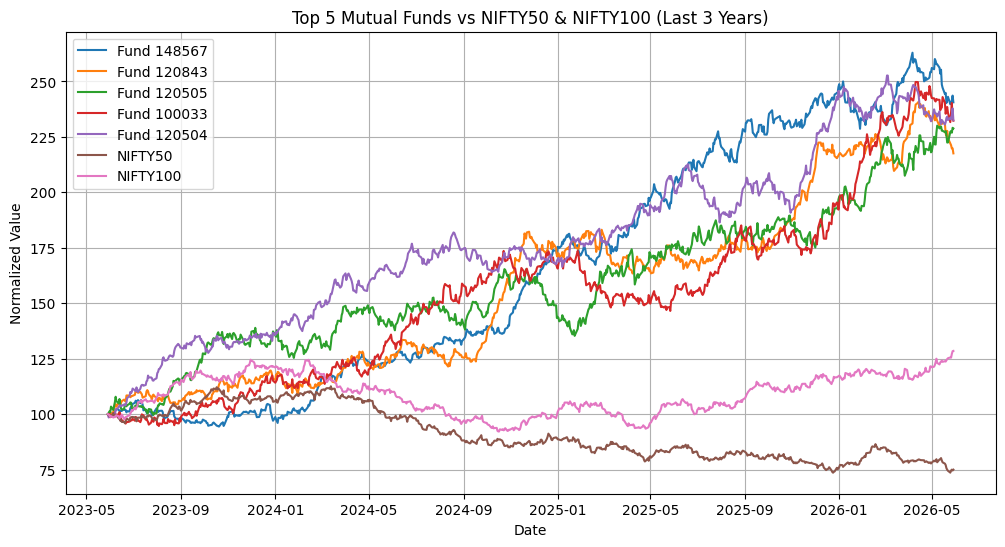

,amfi_code,Tracking_Error
0,148567,0.187974
1,120843,0.206540
2,120505,0.232661
3,100033,0.224976
4,120504,0.187299


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Converting date columns
df['date'] = pd.to_datetime(df['date'])
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

# Selecting top 5 funds from scorecard
top_funds = scorecard.head(5)['amfi_code'].tolist()

# Selecting benchmark data
nifty50_df = benchmark_df[benchmark_df['index_name'] == 'NIFTY50'].copy()

nifty100_df = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()

# Sorting benchmark data
nifty50_df = nifty50_df.sort_values('date')
nifty100_df = nifty100_df.sort_values('date')

# Finding latest date
end_date = df['date'].max()

# Creating 3-year start date
start_date = end_date - pd.DateOffset(years=3)

# Keeping only last 3 years data
nifty50_df = nifty50_df[nifty50_df['date'] >= start_date]

nifty100_df = nifty100_df[ nifty100_df['date'] >= start_date]

# Creating chart
plt.figure(figsize=(12,6))

# Plotting top 5 funds
for fund in top_funds:

    fund_data = df[df['amfi_code'] == fund].copy()

    fund_data = fund_data[ fund_data['date'] >= start_date]

    fund_data = fund_data.sort_values('date')

    # Creating normalized NAV
    fund_data['normalized_nav'] = (fund_data['nav']/ fund_data['nav'].iloc[0]) * 100

    plt.plot( fund_data['date'],fund_data['normalized_nav'],label=f'Fund {fund}')

# Creating normalized NIFTY50
nifty50_df['normalized_value'] = (nifty50_df['close_value']/ nifty50_df['close_value'].iloc[0]) * 100

plt.plot(nifty50_df['date'],nifty50_df['normalized_value'],label='NIFTY50')

# Creating normalized NIFTY100
nifty100_df['normalized_value'] = ( nifty100_df['close_value'] / nifty100_df['close_value'].iloc[0]) * 100

plt.plot(nifty100_df['date'],nifty100_df['normalized_value'],label='NIFTY100')

# Adding chart details
plt.title('Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Last 3 Years)')
plt.xlabel('Date')
plt.ylabel('Normalized Value')

plt.legend()
plt.grid(True)

# Saving chart
plt.savefig('../reports/benchmark_comparison.png',bbox_inches='tight')

plt.show()

# Creating empty list for tracking error
tracking_error_results = []

# Calculating tracking error
for fund in top_funds:

    fund_data = df[df['amfi_code'] == fund].copy()

    fund_data = fund_data.sort_values('date')

    # Creating fund returns
    fund_data['fund_return'] = (fund_data['nav'].pct_change())

    merged_df = pd.merge(fund_data, nifty100_df[['date','close_value']], on='date', how='inner')

    # Creating benchmark returns
    merged_df['benchmark_return'] = ( merged_df['close_value'].pct_change())

    # Calculating tracking error
    tracking_error = (( merged_df['fund_return']- merged_df['benchmark_return']).std()) * np.sqrt(252)

    # Storing result
    tracking_error_results.append({'amfi_code': fund,'Tracking_Error': tracking_error})

# Creating tracking error dataframe
tracking_error_df = pd.DataFrame(tracking_error_results)

tracking_error_df

In [177]:
benchmark_df.groupby('index_name')['close_value'].agg(['min','max']).loc[['NIFTY50','NIFTY100']]

,min,max
index_name,,
NIFTY50,17492.79,27798.72
NIFTY100,14128.86,21088.58


In [178]:
nifty50_df[['date','close_value']].head()
nifty50_df[['date','close_value']].tail()

,date,close_value
1145,2026-05-25,18186.57
1146,2026-05-26,18418.36
1147,2026-05-27,18523.57
1148,2026-05-28,18421.08
1149,2026-05-29,18517.65
